# VPoser
The original body pose space of [SMPL](http://smpl.is.tue.mpg.de/) is not bounded to natural human pose space.
That means you can put a vector value as the pose of a SMPL body model and get a broken body, which might not even look like a human.
To address this issue we replace the original pose space of SMPL with VPoser's latent space (poZ) with known distribution and
correspondence to natural human pose manifold.

The original **body pose** of SMPL is composed of axis-angle representation of 21 joints which in total makes a vector of 63 elements; i.e. 3 rotation reprsentation for each joint.
On the other hand, **body poZ**, VPoser's latent space representation for SMPL body, has in total 32 elements with a spherical Gaussian distribution.
This means if one samples a 32 dimensional random vector from a Normal distribution and pass it through VPoser's decoder the result would be a viable human joint configuration in axis-angle representation.
We introduce "body poZ" as a new representation of human body pose that is fully differentiable and can be used in an end-to-end deep learning pipeline.

In this tutorial we demonstrate how to encode an original body pose into poZ, decode it back to pose and furthermore generate random novel poses from VPoser.
 
First you need to obtain a trained VPoser and a variation of SMPL model, here we use SMPLx, from https://smpl-x.is.tue.mpg.de/downloads.

Put the obtained VPoser and body models in a folder, here we assume respectively

'GITHUB_CLONE_ROOT/human_body_prior/support_data/dowloads/vposer_vXX', and
'GITHUB_CLONE_ROOT/human_body_prior/support_data/dowloads/models/smplx/GENDER/model.npz'


In [1]:
# Set up environment
%load_ext autoreload
%autoreload 2
%matplotlib notebook
%matplotlib inline

import torch
import numpy as np

from body_visualizer.tools.vis_tools import render_smpl_params
from body_visualizer.tools.vis_tools import imagearray2file
from body_visualizer.tools.vis_tools import show_image

In [2]:

#This tutorial requires 'vposer_v2_05'

from os import path as osp
from glob import glob

support_dir = '../support_data/dowloads'
# expr_dir = osp.join(support_dir,'V02_05') #'TRAINED_MODEL_DIRECTORY'  in this directory the trained model along with the model code exist
expr_dir = '../_good_runs/V_me_all' #'TRAINED_MODEL_DIRECTORY'  in this directory the trained model along with the model code exist
bm_fname =  osp.join(support_dir,'models/smplx/neutral/model.npz')#'PATH_TO_SMPLX_model.npz'  obtain from https://smpl-x.is.tue.mpg.de/downloads
sample_amass_fname = osp.join(support_dir, 'amass_sample.npz')# a sample npz file from AMASS

print(expr_dir)
print(bm_fname)
print(sample_amass_fname)

../_good_runs/V_me_all
../support_data/dowloads/models/smplx/neutral/model.npz
../support_data/dowloads/amass_sample.npz


In [3]:
#Loading SMPLx Body Model
from human_body_prior.body_model.body_model import BodyModel

# bm = BodyModel(bm_fname=bm_fname).to('cuda')
bm = BodyModel(bm_fname=bm_fname)

In [4]:
#Loading VPoser Body Pose Prior
from human_body_prior.tools.model_loader import load_model
from human_body_prior.models.vposer_model import VPoser
vp, ps = load_model(expr_dir, model_code=VPoser,
                              remove_words_in_model_weights='vp_model.',
                              disable_grad=True)
# vp = vp.to('cuda')
vp = vp

2025-09-25 13:03:13.036 | INFO     | human_body_prior.tools.model_loader:load_model:77 - No GPU detected. Loading on CPU!
/home/ojas/research/vposer/src/human_body_prior/tools/model_loader.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an is

## Encoding a body_pose (pose>poZ)
We will load an [AMASS](http://amass.is.tue.mpg.de/) sample and place the body pose on the right device for batch processing. To learn more on AMASS data loading refer to [link](https://github.com/nghorbani/amass/blob/master/notebooks/01-AMASS_Visualization.ipynb).

In [5]:
np.load(sample_amass_fname).files
# np.load(sample_amass_fname)['poses'].shape
# 'root_orient': torch.Tensor(bdata['poses'][:, :3]).to(comp_device), # controls the global root orientation (3 values)
# 'pose_body': torch.Tensor(bdata['poses'][:, 3:66]).to(comp_device), # controls the body (63 values)
# 'pose_hand': torch.Tensor(bdata['poses'][:, 66:]).to(comp_device), # controls the finger articulation (90 values)
# see  https://github.com/nghorbani/amass/blob/master/notebooks/01-AMASS_Visualization.ipynb

['poses',
 'dmpls',
 'labels',
 'markers',
 'mocap_framerate',
 'betas',
 'gender',
 'vids',
 'trans']

In [6]:
np.load(sample_amass_fname)['trans'].shape

(500, 3)

In [7]:
# Prepare the pose_body from amass sample
amass_body_pose = np.load(sample_amass_fname)['poses'][:, 3:66]
amass_body_pose = torch.from_numpy(amass_body_pose).type(torch.float)
# amass_body_pose = amass_body_pose.to('cuda')
print('amass_body_pose.shape', amass_body_pose.shape)

amass_body_pose.shape torch.Size([500, 63])


In [8]:
amass_body_poZ = vp.encode(amass_body_pose).mean
print('amass_body_poZ.shape', amass_body_poZ.shape)

amass_body_poZ.shape torch.Size([500, 32])


## Decoding a body_poZ (poZ>pose)
We will decode the same poZ in order to reconstruct the pose and will visualize it for a random frame.

In [9]:
amass_body_pose_rec = vp.decode(amass_body_poZ)['pose_body'].contiguous().view(-1, 63)
print('amass_body_pose_rec.shape', amass_body_poZ.shape)

amass_body_pose_rec.shape torch.Size([500, 32])


In [10]:
##Let's visualize the original pose and the reconstructed one:

t = np.random.choice(len(amass_body_pose))

all_pose_body = torch.stack([amass_body_pose[t], amass_body_pose_rec[t]])

all_pose_body.shape

torch.Size([2, 63])

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: NEEDS EXTENSION: falling back to kms_swrast


(1, 2, 1, 800, 800, 3)


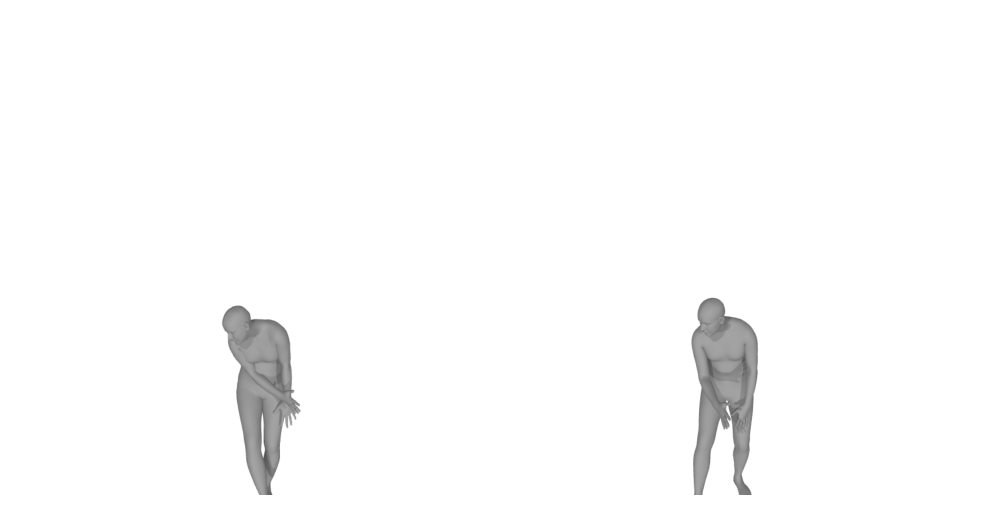

In [11]:
images = render_smpl_params(bm, {'pose_body':all_pose_body}).reshape(1, 2, 1, 800,800,3)
print(images.shape)
img = imagearray2file(images)
show_image(img[0])

The closer above two bodies look similar to each other, the more successful is VPoser is in reconstructing the original data space body pose parameters.

## Generate novel body poses

poZ_body_samples.shape torch.Size([16, 32])
pose_bodies.shape torch.Size([16, 63])


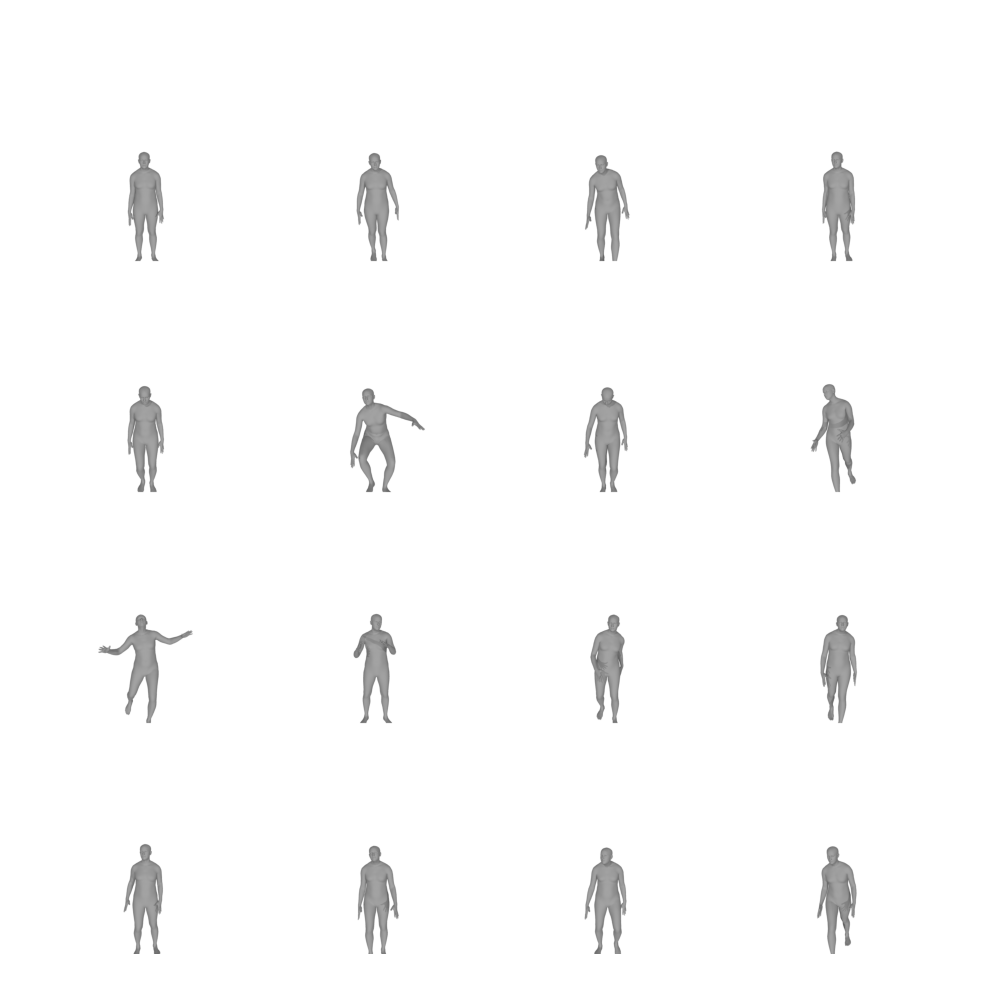

In [12]:
# Sample 16 (4x4) 32-dimensional vectors from a Normal distribution
poZ_body_samples = torch.from_numpy(np.random.randn(16, 32).astype(np.float32))
# poZ_body_samples = poZ_body_samples.cuda()
pose_bodies = vp.decode(poZ_body_samples)['pose_body'].contiguous().view(-1, 63)

print('poZ_body_samples.shape', poZ_body_samples.shape)
print('pose_bodies.shape', pose_bodies.shape)

images = render_smpl_params(bm, {'pose_body': pose_bodies}).reshape(4, 4, 1, 800, 800, 3)
img = imagearray2file(images)
show_image(img[0])

Above we drawn a sample from a 32 dimensional Normal distribution and decoded its value to a full 63 dimensional SMPL body pose vector. The generated image shows the corresponding rendered body. Fo an advanced tutorial on generating poses with VPoser refer to [Link](notebooks/vposer_sampling.ipynb).